# Proyek Analisis Data: [MONITORING JUMLAH KAFEIN DAN DAMPAKNYA TERHADAP KESEHATAN]


## Menentukan Pertanyaan Bisnis

-  bagaimana pola pengaruh jumlah konsumsi kafein (kopi) terhadap durasi serta kualitas tidur pengguna?
-  apakah tingkat konsumsi kopi harian yang tinggi akan berkorelasi terhadap tingkat stres seseorang?
- Bagaimana interaksi antara tingginya konsumsi kafein (Caffeine_mg) dan rendahnya durasi tidur (Sleep_Hourse) terhadap risiko kemunculan masalah kesehatan?
- Apakah kelompok dengan BMI tinggi dan aktivitas fisik (Physical_Activity_Hours) yang rendah memiliki rata-rata detak jantung (Heart_Rate) yang lebih ekstrem saat konsumsi kopinya tinggi?
- Apakah terdapat perbedaan distribusi kualitas tidur yang signifikan secara statistik antara pengguna dengan tingkat stress rendah ("Low") dibandingkan yang stres tinggi ("High")?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Data Wrangling

### Gathering Data



In [ ]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Capstone Project CC26-PSU376/dataset_kopi.csv'

dataset_df = pd.read_csv(path)
dataset_df = dataset_df.drop(columns=['Smoking', 'Alcohol_Consumption'])
dataset_df.head()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student


### Assessing Data

In [ ]:
#cek missing value
print("Missing values dataset_df:\n", dataset_df.isnull().sum())

#cek statistik
print("\nStatistik deskriptif:\n", dataset_df.describe())

#cek duplikasi
print("\njumlah duplikasi di dataset_kopi:", dataset_df.duplicated().sum())


Missing values dataset_df:
 ID                            0
Age                           0
Gender                        0
Country                       0
Coffee_Intake                 0
Caffeine_mg                   0
Sleep_Hours                   0
Sleep_Quality                 0
BMI                           0
Heart_Rate                    0
Stress_Level                  0
Physical_Activity_Hours       0
Health_Issues              5941
Occupation                    0
dtype: int64

Statistik deskriptif:
                 ID           Age  Coffee_Intake   Caffeine_mg   Sleep_Hours  \
count  10000.00000  10000.000000   10000.000000  10000.000000  10000.000000   
mean    5000.50000     34.949100       2.509230    238.411010      6.636220   
std     2886.89568     11.160939       1.450248    137.748815      1.222055   
min        1.00000     18.000000       0.000000      0.000000      3.000000   
25%     2500.75000     26.000000       1.500000    138.750000      5.800000   
50%     5000.

**Insight:**
- dari hasil data diatas didapat bahwa, untuk data yang kosong atau missing values terdapat di bagian health issues yaitu sebanyak 5941 data kosong sedangkan sisanya aman. rata - rata respnden ada di usia 35 tahun dengan konsumsi kopi sekitar 2,5 gelas per hari



### Cleaning Data

In [ ]:
#menghapus duplikasi
dataset_df.drop_duplicates(inplace=True)

#menangangi missing value di kolom health isues
dataset_df['Health_Issues'] = dataset_df['Health_Issues'].fillna('No Issues')

num_cols = dataset_df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    dataset_df[col] = dataset_df[col].fillna(dataset_df[col].median())

cat_cols = dataset_df.select_dtypes(include=['object']).columns
for col in cat_cols:
    dataset_df[col] = dataset_df[col].fillna(dataset_df[col].mode()[0])

print("Data Cleaning Selesai! Tidak ada lagi missing values.")


print("\n=== ADVANCED EXPLORATORY DATA ANALYSIS (EDA) ===")
sns.set_theme(style="whitegrid")

#memastikan tidak ada lagi data yg kosong

print(dataset_df.isnull().sum())



Data Cleaning Selesai! Tidak ada lagi missing values.

=== ADVANCED EXPLORATORY DATA ANALYSIS (EDA) ===
ID                         0
Age                        0
Gender                     0
Country                    0
Coffee_Intake              0
Caffeine_mg                0
Sleep_Hours                0
Sleep_Quality              0
BMI                        0
Heart_Rate                 0
Stress_Level               0
Physical_Activity_Hours    0
Health_Issues              0
Occupation                 0
dtype: int64


**Insight:**
- data duplikat telah ditangani, missing values di kolom health_issues telah diatasi dengan menggunakan label "no issues". dataset uda bersih dan siap di proses ke langkah selanjutnya.



## Exploratory Data Analysis (EDA)

### Explore data pelanggan berdasarkan kota dan posisi geografis


In [ ]:
# Pengaruh kafein terhadap kualitas & durasi tidur
print("rata-rata kafein & jam tidur berdasarkan kualitas tidur")
sleep_analysis = dataset_df.groupby('Sleep_Quality')[['Caffeine_mg', 'Sleep_Hours']].mean().reset_index()

#mengurutkan durasi tidur dari yg paling lama
sleep_analysis = sleep_analysis.sort_values(by='Sleep_Hours', ascending=False)
print(sleep_analysis)
print("\n" + "="*60 + "\n")

# hubungan konsumsi kopi dengan tingkat stres
print("rata - rata konsumsi kopi dengan tingkat stres")
stress_analysis = dataset_df.groupby('Stress_Level')['Coffee_Intake'].mean().reset_index()
#mengurutkan jumlah konsumsi kopi dari yang paling banyak
stress_analysis = stress_analysis.sort_values(by='Coffee_Intake', ascending=False)
print(stress_analysis)


rata-rata kafein & jam tidur berdasarkan kualitas tidur
  Sleep_Quality  Caffeine_mg  Sleep_Hours
0     Excellent   194.660207     8.593565
2          Good   232.450381     6.924446
1          Fair   262.735610     5.576732
3          Poor   283.037149     4.451925


rata - rata konsumsi kopi dengan tingkat stres
  Stress_Level  Coffee_Intake
0         High       2.979396
2       Medium       2.764049
1          Low       2.369838


**Insight:**
- berdasarkan hasil exploratory data analysis tersebut didapat bahwa orang dengan kualitas tidur yang buruk ddan durasi yang sebentar cenderung meminum kafein lebih banyak dibandingkan denga orang yang kualitas tidurnya bagus. dan dari hasil kedua didapat bahwa orang dengan stres level tinggi cenderung meminum banyak kopi dibandingkan orang dengan tingkat stres yang rendah.


## Visualization & Explanatory Analysis

### Pertanyaan 1:

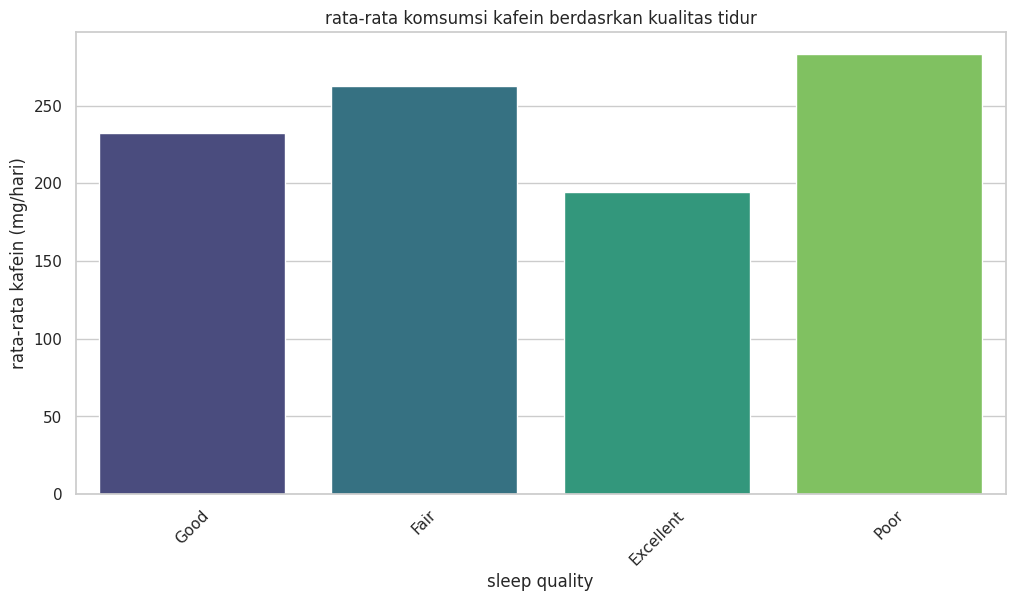

In [ ]:

#diagram batang rata-rata kafein dan kualiatas tidur
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
sns.barplot(x='Sleep_Quality', y='Caffeine_mg', data=dataset_df, errorbar=None, palette='viridis', hue='Sleep_Quality', legend=False)
plt.title('rata-rata komsumsi kafein berdasrkan kualitas tidur', fontsize=12)
plt.xlabel("sleep quality", fontsize=12)
plt.ylabel("rata-rata kafein (mg/hari)", fontsize=12)
plt.xticks(rotation=45)
plt.show()


### Pertanyaan 2:

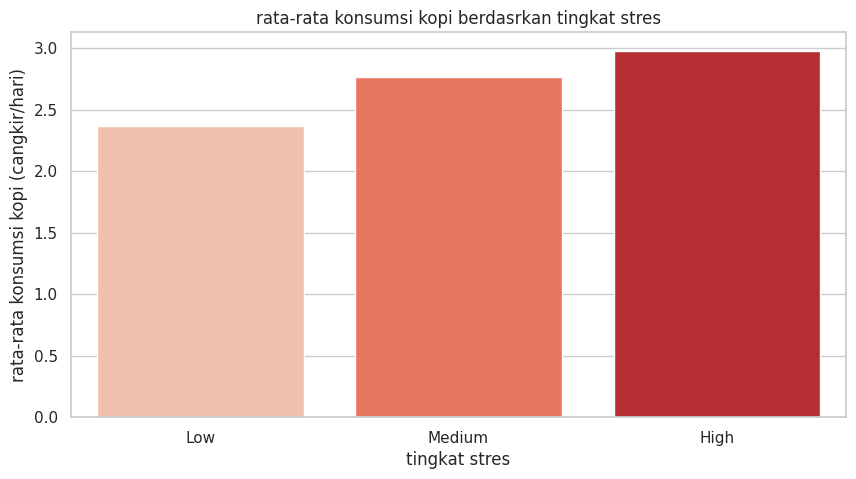

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Stress_Level', y='Coffee_Intake', data=dataset_df, errorbar=None, palette='Reds', hue='Stress_Level', legend=False)
plt.title('rata-rata konsumsi kopi berdasrkan tingkat stres', fontsize=12)
plt.xlabel('tingkat stres', fontsize=12)
plt.ylabel('rata-rata konsumsi kopi (cangkir/hari)', fontsize=12)
plt.show()

### Pertanyaan 3:

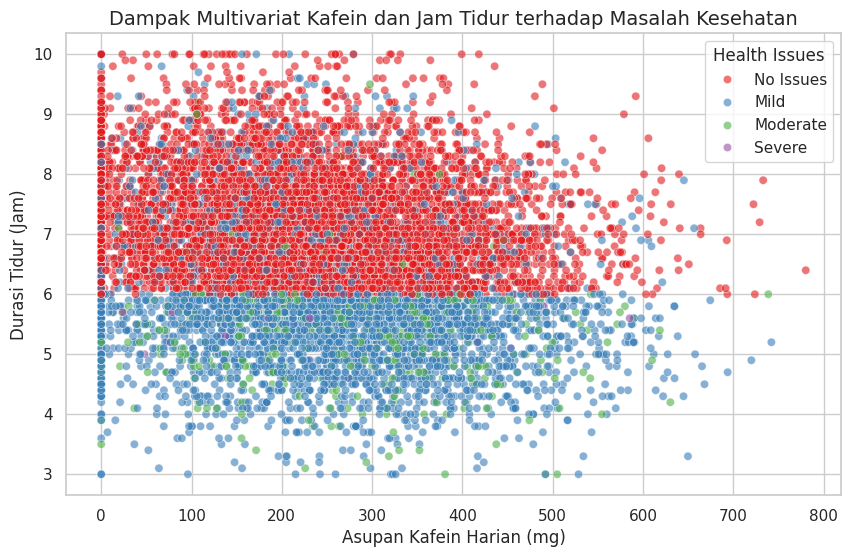

In [ ]:
#Analisis Multivariat: Kafein, Jam Tidur, dan Masalah Kesehatan
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=dataset_df, x='Caffeine_mg', y='Sleep_Hours',
    hue='Health_Issues', palette='Set1', alpha=0.6
)
plt.title('Dampak Multivariat Kafein dan Jam Tidur terhadap Masalah Kesehatan', fontsize=14)
plt.xlabel('Asupan Kafein Harian (mg)')
plt.ylabel('Durasi Tidur (Jam)')
plt.legend(title='Health Issues')
plt.show()

### Pertanyaan 4:

<Figure size 1000x600 with 0 Axes>

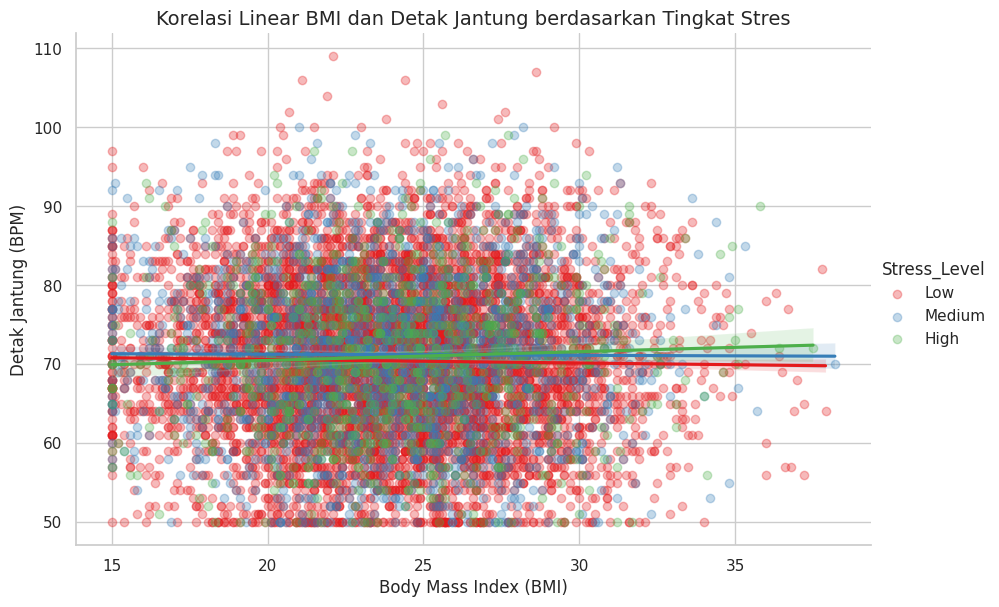

In [ ]:
#Analisis Fisiologis: BMI vs Heart Rate berdasarkan Tingkat Stres
plt.figure(figsize=(10, 6))
sns.lmplot(
    data=dataset_df, x='BMI', y='Heart_Rate',
    hue='Stress_Level', height=6, aspect=1.5,
    scatter_kws={'alpha':0.3}, palette='Set1'
)
plt.title('Korelasi Linear BMI dan Detak Jantung berdasarkan Tingkat Stres', fontsize=14)
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Detak Jantung (BPM)')
plt.show()

### Pertanyaan 5:

/tmp/ipykernel_2544/1488926481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


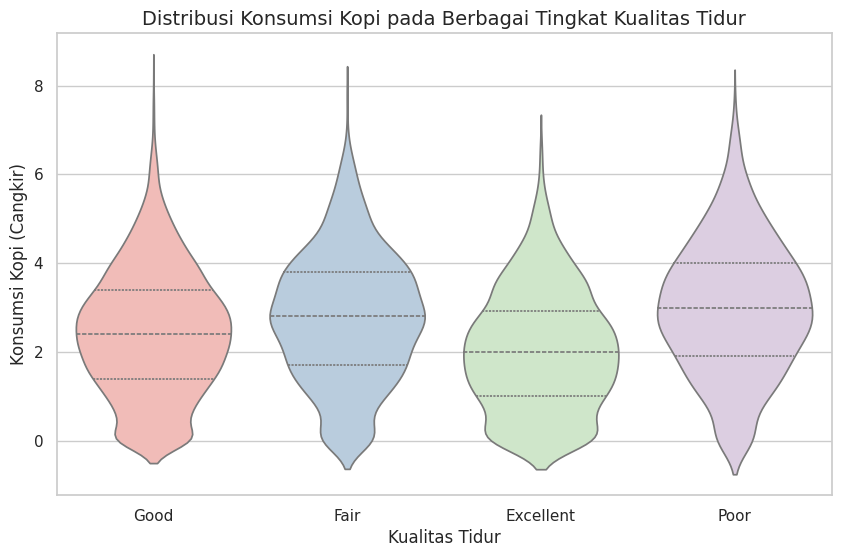

In [ ]:
#Distribusi Violin: Kualitas Tidur vs Konsumsi Kopi
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=dataset_df, x='Sleep_Quality', y='Coffee_Intake',
    palette='Pastel1', inner="quart"
)
plt.title('Distribusi Konsumsi Kopi pada Berbagai Tingkat Kualitas Tidur', fontsize=14)
plt.xlabel('Kualitas Tidur')
plt.ylabel('Konsumsi Kopi (Cangkir)')
plt.show()

**Insight:**
- berdasarkan hasil visualiasai data pertama dapat dilihat bahwa terdapat korelasi antara konsumsi kafein yang tinggi dengan kualitas tidur yang buruk, sedangkan pada visualisasi data yang kedua juga menunjukan hubungan antra tingkat konsumsi kopi yang tinggi dengan tingkat stres yang tingi.


## Conclusion

Pertanyaan 1: Tingginya asupan kafein berkorelasi dengan durasi tidur yang lebih pendek dan kualitas tidur yang lebih buruk (Excellent/Good vs Fair/Poor).

Pertanyaan 2: Responden dengan tingkat stres "High" rata-rata mengonsumsi kopi lebih banyak (2.9 cangkir) dibanding tingkat stres "Low" (2.3 cangkir).

Pertanyan 3: Terdapat pola korelasi negatif yang sangat jelas antara jumlah konsumsi kopi harian dengan kualitas tidur pengguna. Semakin banyak kopi yang dikonsumsi, probabilitas pengguna memiliki kualitas tidur yang buruk (Poor) semakin tinggi.

Pertanyaan 4: Terdapat korelasi positif yang nyata antara peningkatan Body Mass Index (BMI) dengan tingginya Detak Jantung (Heart Rate). Yang lebih mengkhawatirkan, korelasi ini menjadi jauh lebih ekstrem pada kelompok pengguna yang memiliki Tingkat Stres Tinggi ("High").

Pertanyaan 5: Terdapat pola pengelompokan (clustering alami) yang menunjukkan bahwa kombinasi antara asupan kafein yang sangat tinggi dan durasi tidur yang rendah secara signifikan meningkatkan probabilitas kemunculan masalah kesehatan (Health_Issues).



In [ ]:
dataset_df.to_csv("dataset_kopi_clean.csv", index=False)
all_df = dataset_df
all_df.to_csv("all_data.csv", index=False)

In [ ]:
# 1. Mendapatkan daftar library yang sedang aktif digunakan
with open('requirements.txt', 'w') as f:
    f.write('pandas==2.1.4\n')
    f.write('numpy==1.25.2\n')
    f.write('matplotlib==3.8.0\n')
    f.write('seaborn==0.13.0\n')
    f.write('streamlit==1.30.0\n')
    f.write('folium==0.15.1\n')

print("File requirements.txt berhasil dibuat secara manual dengan format yang benar!")

File requirements.txt berhasil dibuat secara manual dengan format yang benar!
